nltk — natural language toolkit 
 
 pymorphy2 —модуль, который позволяет работать с текстами  на русском языке

 itertools — модуль для работы с итераторами


In [ ]:

import sqlalchemy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords

from sklearn.svm import LinearSVC

#from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

from sklearn import metrics
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, HashingVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

import itertools

In [ ]:
pip install pymorphy2

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 55 kB 2.9 MB/s 
     |████████████████████████████████| 8.2 MB 15.4 MB/s 
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13723 sha256=ddddc92fa0cc00addb752e7ef5505d4bd7cb3ef16daa26cb1e04c47acc05ba42
  Stored in directory: /root/.cache/pip/wheels/72/b0/3f/1d95f96ff986c7dfffe46ce2be4062f38ebd04b506c77c81b9
Successfully built docopt


# Новый раздел

In [ ]:
import pymorphy2

In [ ]:
db=sqlalchemy.create_engine('sqlite:////content/drive/MyDrive/books_db.sqlite')
df=pd.read_sql_query('select * from chunk', db, index_col='chunk_id')
db.dispose()
df.head()

,author,book_id,text
chunk_id,,,
1,Иван Алексеевич Бунин,1,"В знак веры в жизнь вечную, в воскресение из м..."
2,Иван Алексеевич Бунин,1,"Ибо он, этот волчец, воистину чудесен. Сорванн..."
3,Иван Алексеевич Бунин,1,"Так утешаюсь и я, воскрешая в себе те светонос..."
4,Иван Алексеевич Бунин,1,"Роза Иерихона. В живую воду сердца, в чистую в..."
5,Иван Алексеевич Бунин,1,"Золотилось солнце на востоке, за туманной синь..."


is_cyr_word —  функция, которая проверяет, написано ли это слово на кириллице

process_text — это функция, которая занимается препроцессингом, предобработкой текста

При помощи функции wordpunct_tokenize модуля nltk текст разделяется на отдельные токены — слова


In [ ]:
morph=pymorphy2.MorphAnalyzer()
def is_cyr_word(word):
    for ch in word:
        if not ('а' <= ch <= 'я'):
            return False
    return True
def process_text(text):        
    lower = (word.lower() for word in nltk.wordpunct_tokenize(text))
    cyr = (word for word in lower if  is_cyr_word(word))
    norm_form = (morph.parse(word)[0].normal_form for word in cyr)
    return ' '.join(norm_form)
  
def shorten_name(name):
  splited=name.split(' ')
  if len(splited) != 3:
    return name
  i,o,f=splited
  return '%s,%s,%s' % (i[0], o[0], f)



In [ ]:
df['words']=df['text'].map(process_text)


In [ ]:
df['author']=df['author'].map(shorten_name)


In [ ]:
df.to_csv('texts_temp.csv',index=False)
df.head()

,author,book_id,text,words
chunk_id,,,,
1,"И,А,Бунин",1,"В знак веры в жизнь вечную, в воскресение из м...",в знак вера в жизнь вечный в воскресение из мё...
2,"И,А,Бунин",1,"Ибо он, этот волчец, воистину чудесен. Сорванн...",ибо он этот волчец воистину чудесный сорвать и...
3,"И,А,Бунин",1,"Так утешаюсь и я, воскрешая в себе те светонос...",так утешаться и я воскрешать в себя тот светон...
4,"И,А,Бунин",1,"Роза Иерихона. В живую воду сердца, в чистую в...",роза иерихон в живой вода сердце в чистый влаг...
5,"И,А,Бунин",1,"Золотилось солнце на востоке, за туманной синь...",золотиться солнце на восток за туманный синь д...


In [ ]:
df=pd.read_csv('texts_temp.csv').dropna()
df[['author','text']].groupby(['author']).count()

,text
author,
"А,П,Платонов",11019
"А,П,Чехов",4359
"А,С,Пушкин",516
"Б,Л,Пастернак",2285
"И,А,Бунин",2490
"И,А,Гончаров",11659
"И,С,Тургенев",6296
"Л,Н,Толстой",4515
"Н,В,Гоголь",1112


Скачиваем стоп-слова...

In [ ]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

..на русском языке

In [ ]:
ru_stop_words=stopwords.words('russian')

In [ ]:
print(ru_stop_words[0:20])

['и', 'в', 'во', 'не', 'что', 'он', 'на', 'я', 'с', 'со', 'как', 'а', 'то', 'все', 'она', 'так', 'его', 'но', 'да', 'ты']


In [ ]:
train, test = train_test_split(df, test_size=0.33)

создаем объект TfidfVectorizer и линейный классификатор LinearSVC

In [ ]:
tf_idf=TfidfVectorizer(max_df=0.7, min_df=5,stop_words=ru_stop_words)
clf=LinearSVC()


задаем пайплайн

In [ ]:
pipeline=Pipeline([('tf_idf',tf_idf),('clf',clf)])

In [ ]:
def plot_confusion_matrix(cm,classes,title='Confusion matrix',cmap=plt.cm.Greens):
  plt.figure(figsize=(20,10))

  cm=cm.astype('float')/cm.sum(axis=1)[:,np.newaxis]*100
  plt.imshow(cm,interpolation='nearest',cmap=cmap)
  plt.title(title)
  plt.colorbar()
  tick_marks=np.arange(len(classes))
  plt.xticks(tick_marks,classes, rotation=45)
  plt.yticks(tick_marks,classes)

  thresh=cm.max()/2.
  for i,j in itertools.product(range(cm.shape[0],cm.shape[1],)):
    plt.text(i,j,'%.2f%%' % cm[i,j], horizontalalignment='center',color='black')
  plt.tight_layout()
  plt.ylabel('True label')
  plt.xlabel('Predicted label')









In [ ]:
def pipe(clf, train, test):
  clf.fit(train['words'],train['author'])

  pred=clf.predict(test['words'])
  score=metrics.f1_score(test['author'], pred, average='micro')
  authors=list(train['author'].unique())
  cm=metrics.confusion_matrix(test['author'], pred,labels=authors)
  plt.figure(figsize=(20,10))
  plot_confusion_matrix(cm, authors)

  return clf, score



F_score 0.8842960179404813


<Figure size 1440x720 with 0 Axes>

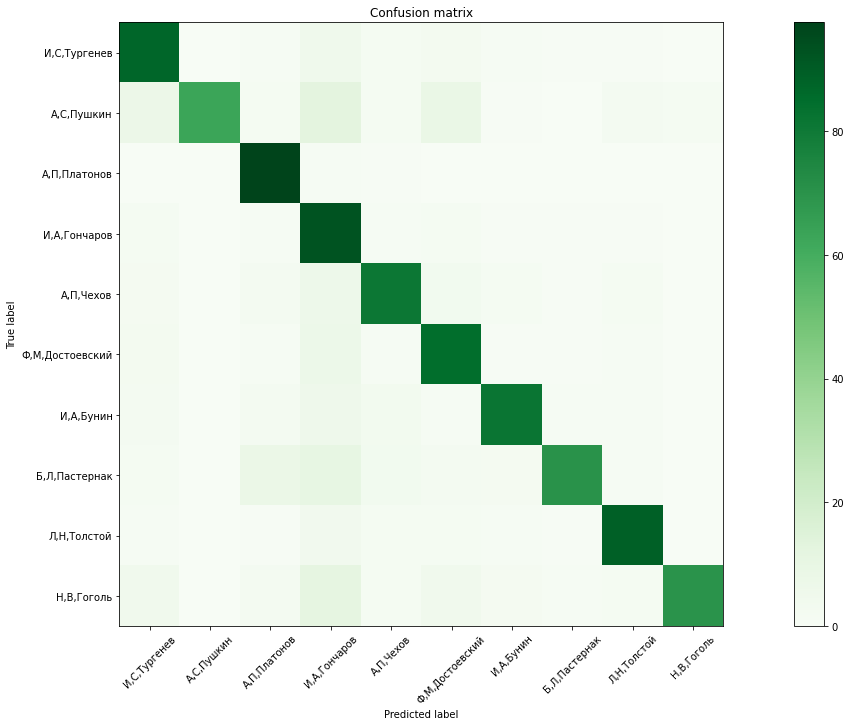

In [ ]:
clf, score = pipe(pipeline,train,test)
print('F_score',score)
plt.show()

**WordToVec**

Разобьем текст на предложения

In [ ]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
tokenizer=nltk.data.load('tokenizers/punkt/english.pickle')


In [ ]:
def chunk_to_sentences(text):
  raw_sentences=tokenizer.tokenize(text.strip())
  sentences=[]
  for sentence in raw_sentences:
    lower=(word.lower() for word in nltk.wordpunct_tokenize(sentence))
    cyr = (word for word in lower if  is_cyr_word(word))
    norm_form = list(morph.parse(word)[0].normal_form for word in cyr)
    if len(norm_form)>0:
      sentences.append(norm_form)
  return sentences

In [ ]:
df['sentences']=df['text'].map(chunk_to_sentences)

In [ ]:
rows=[]
for i, row in df.iterrows():
  for sent in row.sentences:
    new_row=[' '.join(sent)]
    new_row.extend(row.tolist()[:-1])
    rows.append(new_row )

In [ ]:
df_sent=pd.DataFrame(rows,columns=['sentences','author','id','test','words'])
df_sent.to_csv('with_sentences.csv',index=False)
df_sent

,sentences,author,id,test,words
0,в знак вера в жизнь вечный в воскресение из мё...,"И,А,Бунин",1,"В знак веры в жизнь вечную, в воскресение из м...",в знак вера в жизнь вечный в воскресение из мё...
1,странно что назвать роза да ещё роза иерихон э...,"И,А,Бунин",1,"В знак веры в жизнь вечную, в воскресение из м...",в знак вера в жизнь вечный в воскресение из мё...
2,ибо он этот волчец воистину чудесный,"И,А,Бунин",1,"Ибо он, этот волчец, воистину чудесен. Сорванн...",ибо он этот волчец воистину чудесный сорвать и...
3,сорвать и унести странник за тысяча верста от ...,"И,А,Бунин",1,"Ибо он, этот волчец, воистину чудесен. Сорванн...",ибо он этот волчец воистину чудесный сорвать и...
4,но быть положить в вода тотчас начинать распус...,"И,А,Бунин",1,"Ибо он, этот волчец, воистину чудесен. Сорванн...",ибо он этот волчец воистину чудесный сорвать и...
...,...,...,...,...,...
227313,любимый поговорка а вот позволить я сичас сича...,"И,С,Тургенев",47,"С одной стороны рта зубов нет, так что все лиц...",с один сторона рот зуб нет так что всё лицо не...
227314,рука назад как приказать,"И,С,Тургенев",47,"С одной стороны рта зубов нет, так что все лиц...",с один сторона рот зуб нет так что всё лицо не...
227315,трус естественный,"И,С,Тургенев",47,"С одной стороны рта зубов нет, так что все лиц...",с один сторона рот зуб нет так что всё лицо не...
227316,я взять с себя когда послать он харлов,"И,С,Тургенев",47,"С одной стороны рта зубов нет, так что все лиц...",с один сторона рот зуб нет так что всё лицо не...


In [ ]:
df_sent=pd.read_csv('with_sentences.csv')

In [ ]:
import gensim

In [ ]:
num_features=150
context=5
min_word_count=3
num_workers=4
from gensim.models import word2vec

In [ ]:
import logging

In [ ]:
logging.basicConfig(format='%(asctime)s ; %(levelname)s; %(message)s',  level=logging.INFO)

In [ ]:
print('Training model')
model=word2vec.Word2Vec([s.split(' ') for s in df_sent['sentences'].values],workers=num_workers, size=num_features,min_count=min_word_count,window=context)


Training model


Заменим исходные векторы нормализованными. После этого модель будет работать быстрее, но огбучать ее уже нельзя.

In [ ]:
model.init_sims(replace=True)

In [ ]:
model_name='150Features_Scontext'
model.save(model_name)


In [ ]:
print('лишний: мать кот собака лошадь: ' + model.doesnt_match('мать кот собака лошадь'.split()))
print('лишний: кастрюля кот собака лошадь: ' + model.doesnt_match('кастрюля кот собака лошадь'.split()))
print('лишний: киборг кот собака лошадь: ' + model.doesnt_match('киборг кот собака лошадь'.split()))
print('лишний: франция москва петербург париж: ' + model.doesnt_match('франция москва петербург париж'.split()))

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: DeprecationWarning: Call to deprecated `doesnt_match` (Method will be removed in 4.0.0, use self.wv.doesnt_match() instead).
  """Entry point for launching an IPython kernel.
/usr/local/lib/python3.7/dist-packages/gensim/models/keyedvectors.py:895: FutureWarning: arrays to stack must be passed as a "sequence" type such as list or tuple. Support for non-sequence iterables such as generators is deprecated as of NumPy 1.16 and will raise an error in the future.
  vectors = vstack(self.word_vec(word, use_norm=True) for word in used_words).astype(REAL)
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: DeprecationWarning: Call to deprecated `doesnt_match` (Method will be removed in 4.0.0, use self.wv.doesnt_match() instead).
  
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: DeprecationWarning: Call to deprecated `doesnt_match` (Method will be removed in 4.0.0, use self.wv.doesnt_match() instead).
 

лишний: мать кот собака лошадь: мать
лишний: кастрюля кот собака лошадь: лошадь
лишний: киборг кот собака лошадь: кот
лишний: франция москва петербург париж: франция


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:4: DeprecationWarning: Call to deprecated `doesnt_match` (Method will be removed in 4.0.0, use self.wv.doesnt_match() instead).
  after removing the cwd from sys.path.


In [ ]:
print( str(model.similar_by_word('отец')))

[('мать', 0.8845176100730896), ('жена', 0.856997013092041), ('сын', 0.8406203389167786), ('сестра', 0.8375627398490906), ('муж', 0.8207378387451172), ('родный', 0.8040156960487366), ('брат', 0.7686594128608704), ('дочь', 0.743361234664917), ('тётка', 0.7333126664161682), ('ребёнок', 0.7221487760543823)]


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: DeprecationWarning: Call to deprecated `similar_by_word` (Method will be removed in 4.0.0, use self.wv.similar_by_word() instead).
  """Entry point for launching an IPython kernel.


In [ ]:
print( str(model.similar_by_vector('жена')))

[('сын', 0.9039391279220581), ('муж', 0.8997783660888672), ('сестра', 0.8671930432319641), ('отец', 0.856997013092041), ('мать', 0.8316807746887207), ('дочь', 0.799939751625061), ('брат', 0.7842164635658264), ('тётка', 0.7743588089942932), ('невеста', 0.749213457107544), ('ребёнок', 0.7460973262786865)]


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: DeprecationWarning: Call to deprecated `similar_by_vector` (Method will be removed in 4.0.0, use self.wv.similar_by_vector() instead).
  """Entry point for launching an IPython kernel.


In [ ]:
print( str(model.similar_by_vector('корабль')))

[('батарея', 0.8951923251152039), ('остров', 0.8940154910087585), ('луг', 0.8865094184875488), ('судно', 0.8819202184677124), ('пароход', 0.8764225840568542), ('избушка', 0.8729555606842041), ('стадо', 0.8704171776771545), ('постройка', 0.8687183856964111), ('пруд', 0.8672974705696106), ('завод', 0.8670785427093506)]


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: DeprecationWarning: Call to deprecated `similar_by_vector` (Method will be removed in 4.0.0, use self.wv.similar_by_vector() instead).
  """Entry point for launching an IPython kernel.


In [ ]:
print( str(model.similar_by_word('корабль')))

[('батарея', 0.8951923251152039), ('остров', 0.8940154910087585), ('луг', 0.8865094184875488), ('судно', 0.8819202184677124), ('пароход', 0.8764225840568542), ('избушка', 0.8729555606842041), ('стадо', 0.8704171776771545), ('постройка', 0.8687183856964111), ('пруд', 0.8672974705696106), ('завод', 0.8670785427093506)]


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: DeprecationWarning: Call to deprecated `similar_by_word` (Method will be removed in 4.0.0, use self.wv.similar_by_word() instead).
  """Entry point for launching an IPython kernel.
